# Section 3 — RM Productivity
**Apex Asset Management case study · Agent 2 (Analysis) · as-of 2026-05-31**

Acquisition metrics are attributed on the **Introducer** role (who onboarded the account) per `definitions.rm` — never blended with the servicing book. We score the 16 official RMs on volume **and** quality (1-year cohort retention), map the volume×value quadrant, measure fund specialisation via **HHI**, and read the team's year-over-year trajectory to separate **systemic** from **individual** problems.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import _common as C
defs=C.load_defs(); C.set_style(); SEC='section3'; AS_OF=C.AS_OF
acc=C.load_accounts(); mf=C.load_monthly_flows()
FUNDS=defs['funds']; SHORT=C.FUND_SHORT; COL=C.FUND_COLORS; metrics={}
# Official-RM introduced book (acquisition role)
intro=acc[acc.introducer_in_rmlist].copy()
print('accounts introduced by the 16 official RMs:', len(intro), 'of', len(acc))
print('distinct official introducer RMs:', intro.introducer_rm_name_canon.nunique())

accounts introduced by the 16 official RMs: 5903 of 12229
distinct official introducer RMs: 16


## 3.1 RM scorecard (acquisition role = Introducer)
Per RM: unique customers onboarded, accounts introduced, average installment, **AUM introduced** (current book value of accounts they onboarded), onboarding capital, and headline leakage of their book.

In [2]:
def rm_card(df):
    g=df.groupby('introducer_rm_name_canon')
    sc=g.agg(accounts=('registration_no','size'),
             customers=('mobile_no','nunique'),
             avg_installment=('current_installment_amount','mean'),
             aum_introduced=('investment_value_market','sum'),
             onboarding_capital=('onboarding_amount','sum'),
             sip_share=('is_sip','mean'))
    rate=df[~df.excluded_from_rates]
    rr=rate.groupby('introducer_rm_name_canon').agg(
        churn_strict=('churn_strict','mean'),
        active_now=('is_active','mean'))
    return sc.join(rr)
card=rm_card(intro).sort_values('aum_introduced',ascending=False)
C.save_table(card,SEC,'rm_scorecard')
metrics['rm_scorecard']=card.reset_index().to_dict('records')
disp=card.copy()
disp['avg_installment']=disp.avg_installment.round(0)
disp['aum_introduced_Cr']=(disp.aum_introduced/1e7).round(2)
disp['onboarding_Cr']=(disp.onboarding_capital/1e7).round(2)
for c in ['sip_share','churn_strict','active_now']: disp[c]=(disp[c]*100).round(1)
disp[['accounts','customers','avg_installment','aum_introduced_Cr','onboarding_Cr','sip_share','churn_strict','active_now']]

,accounts,customers,avg_installment,aum_introduced_Cr,onboarding_Cr,sip_share,churn_strict,active_now
introducer_rm_name_canon,,,,,,,,
MST. SHANTA SHEIKH,976,643,17314.0,34.79,16.39,91.4,36.3,59.8
SHARIFA BEGUM,691,511,16619.0,21.40,10.24,92.5,27.2,69.9
SHIBANI DATTA,832,633,12658.0,16.33,7.82,93.1,29.9,66.7
MOHAMMAD JASIM AHMED,727,522,13756.0,14.80,6.88,94.4,24.6,72.4
KAZI JALAL RANA,455,364,17123.0,10.66,4.79,95.2,15.8,81.8
JANNATUL ISLAM,495,403,13430.0,6.44,2.60,95.6,11.1,87.1
MST. SHARMIN BHUIYAN,322,249,10484.0,5.64,3.77,91.0,16.5,80.1
MOST. KAMRUN MIA,370,293,10869.0,5.60,3.25,97.0,11.4,86.8
MOST. SUMAYA SIDDIQUE,325,237,15112.0,4.54,3.37,97.2,24.3,74.5


## 3.2 Per-RM 1-year cohort retention — *acquisition quality*
Volume without retention is churned AUM. For every account we reconstruct its **point-in-time status at onboarding + 12 months** (using dated close/discontinue events, not the current snapshot — see `decisions_log.md`), restricted to accounts old enough to observe that outcome (onboarded ≤ as-of − 12m). Per-RM 1-yr retention = share of their introduced cohort still alive (not strict-churned) at month 12. **High volume + low retention = the flag to coach.**

In [3]:
# observable 12-month cohort: onboarded on/before AS_OF - 12 months
cut = AS_OF - pd.DateOffset(months=12)
obs = intro[intro.first_purchase_date<=cut].copy()
measure = obs.first_purchase_date + pd.DateOffset(months=12)
closed_by = obs.account_closing_date.notna() & (obs.account_closing_date<=measure)
disc_by   = obs.sip_discontinuation_date.notna() & (obs.sip_discontinuation_date<=measure)
obs['retained_12m'] = ~(closed_by|disc_by)
ret=obs.groupby('introducer_rm_name_canon').agg(
    cohort_n=('retained_12m','size'), retention_1yr=('retained_12m','mean'))
card=card.join(ret)
metrics['rm_retention_1yr']=ret.reset_index().to_dict('records')
metrics['overall_retention_1yr']=float(obs.retained_12m.mean())
print(f'Overall 1-yr cohort retention (official-RM book): {obs.retained_12m.mean():.1%}  (n={len(obs)})')
C.save_table(card,SEC,'rm_scorecard_with_retention')
(ret.assign(retention_1yr=(ret.retention_1yr*100).round(1)).sort_values('retention_1yr'))

Overall 1-yr cohort retention (official-RM book): 86.2%  (n=3301)


,cohort_n,retention_1yr
introducer_rm_name_canon,,
MOST. SUMAYA SIDDIQUE,98,74.5
MOHAMMAD JASIM AHMED,422,83.4
MST. RINA AKTER,143,84.6
MOST. KAMRUN MIA,144,84.7
JANNATUL ISLAM,197,85.8
MST. SHARMIN BHUIYAN,165,86.1
SHIBANI DATTA,542,86.3
KAZI JALAL RANA,235,86.4
SHARIFA BEGUM,477,87.6


In [4]:
# Case-specified 1-yr retention (May-2024 cohort -> May-2025), reconstructed point-in-time
co=defs['cohorts']['one_year_retention']
acc_all=acc[~acc.excluded_from_rates]
c0=acc_all[acc_all.onboarding_month==co['cohort_month']].copy()
meas=pd.Timestamp(co['measured_at']+'-28') + pd.offsets.MonthEnd(0)
cb=c0.account_closing_date.notna()&(c0.account_closing_date<=meas)
db=c0.sip_discontinuation_date.notna()&(c0.sip_discontinuation_date<=meas)
c0['retained']=~(cb|db)
metrics['case_2024_05_retention']=dict(cohort_month=co['cohort_month'],measured_at=co['measured_at'],
    denominator=int(len(c0)), numerator=int(c0.retained.sum()), rate=float(c0.retained.mean()))
print(f"Case cohort {co['cohort_month']} -> {co['measured_at']}: "
      f"{int(c0.retained.sum())}/{len(c0)} retained = {c0.retained.mean():.1%}")

Case cohort 2024-05 -> 2025-05: 115/136 retained = 84.6%


## 3.3 Volume × value quadrant + retention overlay
x = customers onboarded (volume), y = AUM introduced per customer (value). Split at medians. Bubble size = cohort size; colour = 1-yr retention. The dangerous quadrant is **high-volume, low-value/low-retention** — RMs spraying low-quality sign-ups.

D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


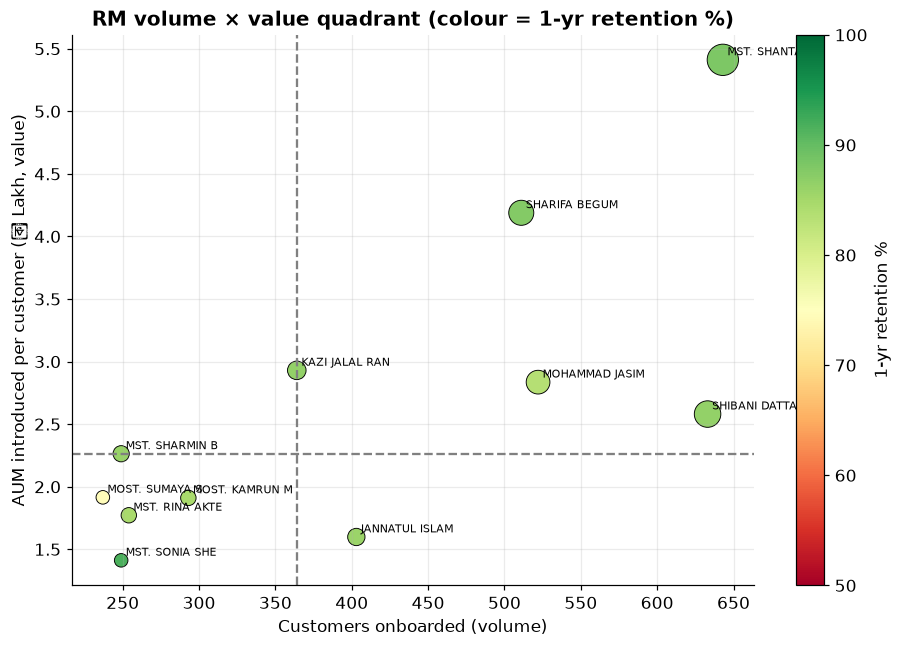

High-volume / low-retention RMs to coach: ['MOHAMMAD JASIM AHMED', 'JANNATUL ISLAM']


In [5]:
q=card.dropna(subset=['retention_1yr']).copy()
q['aum_per_customer']=q.aum_introduced/q.customers
vmed=q.customers.median(); amed=q.aum_per_customer.median()
metrics['quadrant_medians']=dict(volume_median=float(vmed), value_median=float(amed))
fig,ax=plt.subplots(figsize=(10,6.5))
sc=ax.scatter(q.customers, q.aum_per_customer/1e5, s=q.cohort_n/2+30,
    c=q.retention_1yr*100, cmap='RdYlGn', vmin=50, vmax=100, edgecolor='k', linewidth=.6)
ax.axvline(vmed,ls='--',color='grey'); ax.axhline(amed/1e5,ls='--',color='grey')
for n,r in q.iterrows(): ax.annotate(str(n)[:14], (r.customers, r.aum_per_customer/1e5), fontsize=7,
    xytext=(3,3), textcoords='offset points')
ax.set_xlabel('Customers onboarded (volume)'); ax.set_ylabel('AUM introduced per customer (৳ Lakh, value)')
ax.set_title('RM volume × value quadrant (colour = 1-yr retention %)')
plt.colorbar(sc,label='1-yr retention %')
C.savefig(fig,SEC,'01_rm_quadrant'); plt.show()
# explicit high-volume/low-quality flag
flag=q[(q.customers>=vmed)&(q.retention_1yr<q.retention_1yr.median())]
metrics['high_vol_low_quality_rms']=flag.index.tolist()
print('High-volume / low-retention RMs to coach:', flag.index.tolist())

## 3.4 Fund specialisation via HHI
For each RM, HHI of their introduced accounts across the 4 funds (Σ shareᵢ², ×10,000). ~10,000 = one-fund specialist; ~2,500 = perfectly diversified. Specialists are efficient to deploy on their fund but a single-fund concentration risk; generalists are flexible.

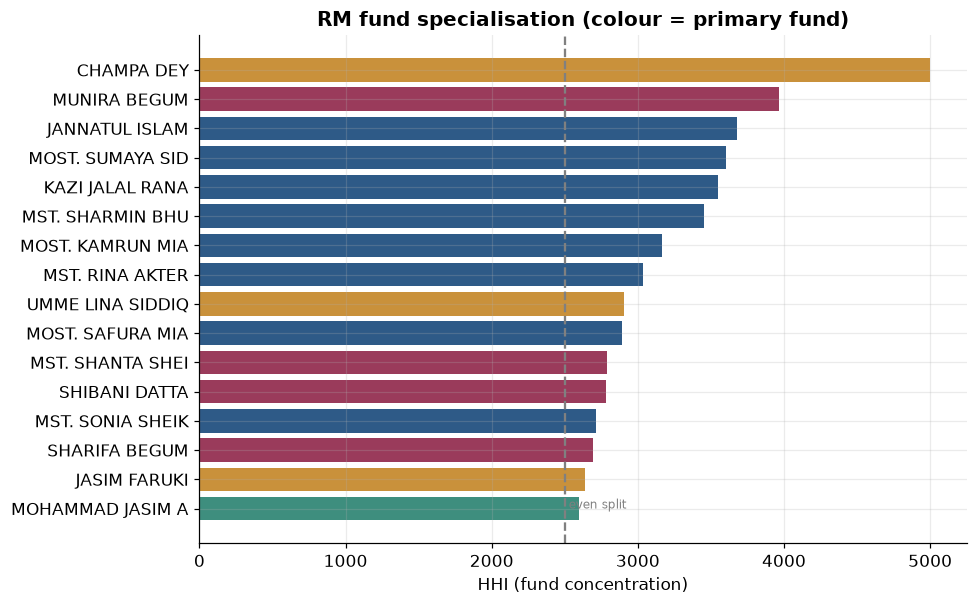

,HHI,primary_fund,accounts
introducer_rm_name_canon,,,
CHAMPA DEY,5000.0,Apex Balanced Opportunity Fund,2
MUNIRA BEGUM,3964.0,Apex Capital Growth Fund,13
JANNATUL ISLAM,3679.0,Apex Fixed Income Fund,495
MOST. SUMAYA SIDDIQUE,3602.0,Apex Fixed Income Fund,325
KAZI JALAL RANA,3548.0,Apex Fixed Income Fund,455
MST. SHARMIN BHUIYAN,3456.0,Apex Fixed Income Fund,322
MOST. KAMRUN MIA,3169.0,Apex Fixed Income Fund,370
MST. RINA AKTER,3037.0,Apex Fixed Income Fund,316
UMME LINA SIDDIQUE,2909.0,Apex Balanced Opportunity Fund,19


In [6]:
def hhi(s):
    p=s.value_counts(normalize=True); return float((p**2).sum()*10000)
hh=intro.groupby('introducer_rm_name_canon').fund.apply(hhi).rename('HHI')
top_fund=intro.groupby('introducer_rm_name_canon').fund.agg(lambda s:s.value_counts().idxmax())
spec=pd.DataFrame({'HHI':hh,'primary_fund':top_fund,'accounts':intro.groupby('introducer_rm_name_canon').size()})
spec=spec.sort_values('HHI',ascending=False)
C.save_table(spec,SEC,'rm_specialization_hhi')
metrics['rm_hhi']=spec.reset_index().to_dict('records')
fig,ax=plt.subplots(figsize=(9,6))
order=spec.sort_values('HHI').index
cols=[COL[spec.loc[n,'primary_fund']] for n in order]
ax.barh([str(n)[:16] for n in order], spec.loc[order,'HHI'], color=cols)
ax.axvline(2500,ls='--',color='grey'); ax.text(2500,0,' even split',fontsize=8,color='grey')
ax.set_xlabel('HHI (fund concentration)'); ax.set_title('RM fund specialisation (colour = primary fund)')
C.savefig(fig,SEC,'02_rm_hhi'); plt.show()
spec.round(0)

## 3.5 Team year-over-year — systemic vs individual
Team trajectory by onboarding year: accounts introduced, 1-yr cohort retention of each vintage, and net flow attributed to that vintage. A falling team-wide retention line is a **systemic** signal (process/incentive); a single RM diverging is **individual** (coaching).

D:\GitHub\apex\analysis\_common.py:169: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.savefig(p)


D:\GitHub\apex\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2547 (\N{BENGALI RUPEE SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


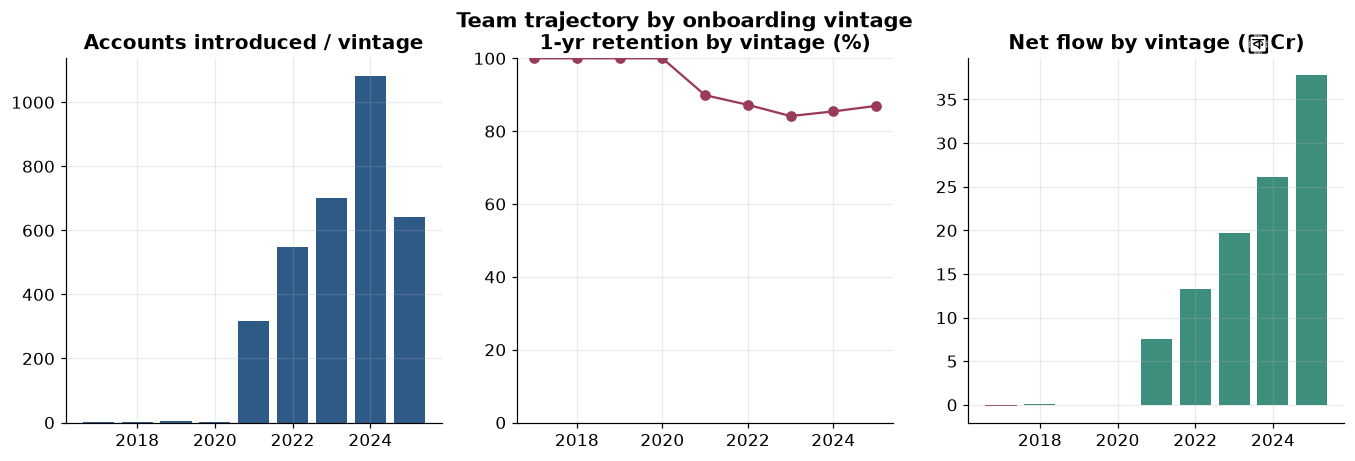

,introduced,retention_1yr,net_flow_Cr
onboarding_year,,,
2017,2,100.0,-0.13
2018,2,100.0,0.11
2019,4,100.0,0.00
2020,3,100.0,-0.02
2021,316,89.9,7.51
2022,548,87.2,13.26
2023,700,84.1,19.71
2024,1083,85.4,26.11
2025,643,86.9,37.82


In [7]:
# vintage retention: reuse point-in-time +12m on the official-RM book by onboarding year
obs_y=intro[intro.first_purchase_date<=cut].copy()
m2=obs_y.first_purchase_date+pd.DateOffset(months=12)
obs_y['retained_12m']=~((obs_y.account_closing_date.notna()&(obs_y.account_closing_date<=m2)) |
                        (obs_y.sip_discontinuation_date.notna()&(obs_y.sip_discontinuation_date<=m2)))
team=obs_y.groupby('onboarding_year').agg(introduced=('registration_no','size'),
    retention_1yr=('retained_12m','mean'))
# net flow by introducing vintage
nf=mf.merge(intro[['registration_no','onboarding_year']],left_on='account_number',right_on='registration_no')
nf_y=nf.groupby('onboarding_year').net_flow.sum()
team['net_flow']=nf_y
C.save_table(team,SEC,'team_yoy')
metrics['team_yoy']=team.reset_index().to_dict('records')
fig,ax=plt.subplots(1,3,figsize=(15,4.3))
yy=team.index.astype(int)
ax[0].bar(yy,team.introduced,color='#2E5A87'); ax[0].set_title('Accounts introduced / vintage')
ax[1].plot(yy,team.retention_1yr*100,'o-',color='#9A3B5B'); ax[1].set_title('1-yr retention by vintage (%)'); ax[1].set_ylim(0,100)
ax[2].bar(yy,team.net_flow/1e7,color=['#3E8E7E' if v>=0 else '#9A3B5B' for v in team.net_flow]); ax[2].set_title('Net flow by vintage (৳Cr)')
fig.suptitle('Team trajectory by onboarding vintage', fontsize=14, fontweight='bold')
C.savefig(fig,SEC,'03_team_yoy'); plt.show()
team.assign(retention_1yr=(team.retention_1yr*100).round(1), net_flow_Cr=(team.net_flow/1e7).round(2)).drop(columns='net_flow')

In [8]:
C.dump_metrics(SEC,metrics)
print('Section 3 metrics persisted.')
print('figures:', sorted(p.name for p in (C.ANALYSIS/SEC/'figures').glob('*.png')))
print('tables :', sorted(p.name for p in (C.ANALYSIS/SEC/'tables').glob('*.csv')))

Section 3 metrics persisted.
figures: ['01_rm_quadrant.png', '02_rm_hhi.png', '03_team_yoy.png']
tables : ['rm_scorecard.csv', 'rm_scorecard_with_retention.csv', 'rm_specialization_hhi.csv', 'team_yoy.csv']


## 3.6 Section-3 findings (each a Monday decision)
- **Rank RMs on retention-adjusted volume, not raw sign-ups.** The volume×value quadrant flags high-volume/low-retention RMs whose AUM leaks back out within a year — coach or re-incentivise them.
- **Specialists vs generalists are different tools:** high-HHI RMs are efficient to deploy on their fund; pair them with the fund that needs growth (Section 1) rather than re-training them.
- **Read the vintage retention line for systemic drift:** if team-wide 1-yr retention is falling across vintages, the fix is process/incentive (systemic), not individual coaching.
- Acquisition (Introducer) and book (Service) are kept separate so we don't credit a servicing RM for another's onboarding.